In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve, auc, 
                             classification_report, confusion_matrix, accuracy_score, brier_score_loss)
from sklearn.calibration import calibration_curve


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

import keras_tuner as kt

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

2026-05-02 15:42:15.598379: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777736535.985539      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777736536.088658      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777736537.075005      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777736537.075045      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777736537.075047      23 computation_placer.cc:177] computation placer alr

In [2]:
PATH = '/kaggle/input/notebooks/yasminabouziane/data-rainprediction/' 
print("Chargement des données...")

X_train_raw = pd.read_csv(os.path.join(PATH, 'X_train.csv'))
y_train_raw = pd.read_csv(os.path.join(PATH, 'y_train.csv'))['RainTomorrow']
X_test = pd.read_csv(os.path.join(PATH, 'X_test.csv'))
y_test = pd.read_csv(os.path.join(PATH, 'y_test.csv'))['RainTomorrow']

# CRITÈRE : Stabilité des données (Conversion en float32 pour Keras)
X_train = np.asarray(X_train_raw).astype('float32')
y_train = np.asarray(y_train_raw).astype('float32')
X_test_k = np.asarray(X_test).astype('float32')
y_test_k = np.asarray(y_test).astype('float32')

print(f"Données chargées : Train={X_train.shape}, Test={X_test.shape}")

Chargement des données...
Données chargées : Train=(113754, 115), Test=(28439, 115)


In [3]:
print("\nRecherche des meilleurs hyperparamètres (Tuning)...")

import os
import shutil
import keras_tuner as kt
from tensorflow.keras.metrics import AUC

dossier_tuning = 'my_dir'
if os.path.exists(dossier_tuning):
    shutil.rmtree(dossier_tuning)

def build_model(hp):
    """Fonction qui définit l'espace de recherche pour le réseau de neurones."""
    model = Sequential()
    
    # Tuning du nombre de neurones et du taux de Dropout
    model.add(Dense(units=hp.Int('units_1', min_value=64, max_value=256, step=64), 
                    activation='relu', input_shape=(X_train.shape[1],)))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float('drop_1', min_value=0.2, max_value=0.5, step=0.1)))
    
    model.add(Dense(units=hp.Int('units_2', min_value=32, max_value=128, step=32), 
                    activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float('drop_2', min_value=0.1, max_value=0.4, step=0.1)))
    
    model.add(Dense(1, activation='sigmoid'))
    
    # Tuning du Learning Rate
    lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    
    model.compile(optimizer=Adam(learning_rate=lr), 
                  loss='binary_crossentropy', 
                  metrics=[AUC(name='auc')])
    
    return model

# Configuration de la recherche
tuner = kt.RandomSearch(
    build_model,
    objective=kt.Objective("val_auc", direction="max"), # Cherche maintenant la bonne clé
    max_trials=3, 
    directory=dossier_tuning,
    project_name='rain_tuning'
)

# Surveillance du sur-apprentissage (EarlyStopping)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Lancement de la recherche avec validation
tuner.search(X_train, y_train, epochs=20, validation_split=0.2, callbacks=[early_stop], verbose=1)

# Récupération du meilleur modèle entraîné
mlp_model = tuner.get_best_models(num_models=1)[0]
y_pred_proba_mlp = mlp_model.predict(X_test_k).ravel()

print(f"\nTuning terminé ! Meilleure architecture : {tuner.get_best_hyperparameters()[0].values}")

Trial 3 Complete [00h 02m 24s]
val_auc: 0.901524543762207

Best val_auc So Far: 0.9019296169281006
Total elapsed time: 00h 07m 18s
889/889 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

Tuning terminé ! Meilleure architecture : {'units_1': 64, 'drop_1': 0.2, 'units_2': 64, 'drop_2': 0.1, 'learning_rate': 0.001}



Évaluation des performances et de la Calibration...


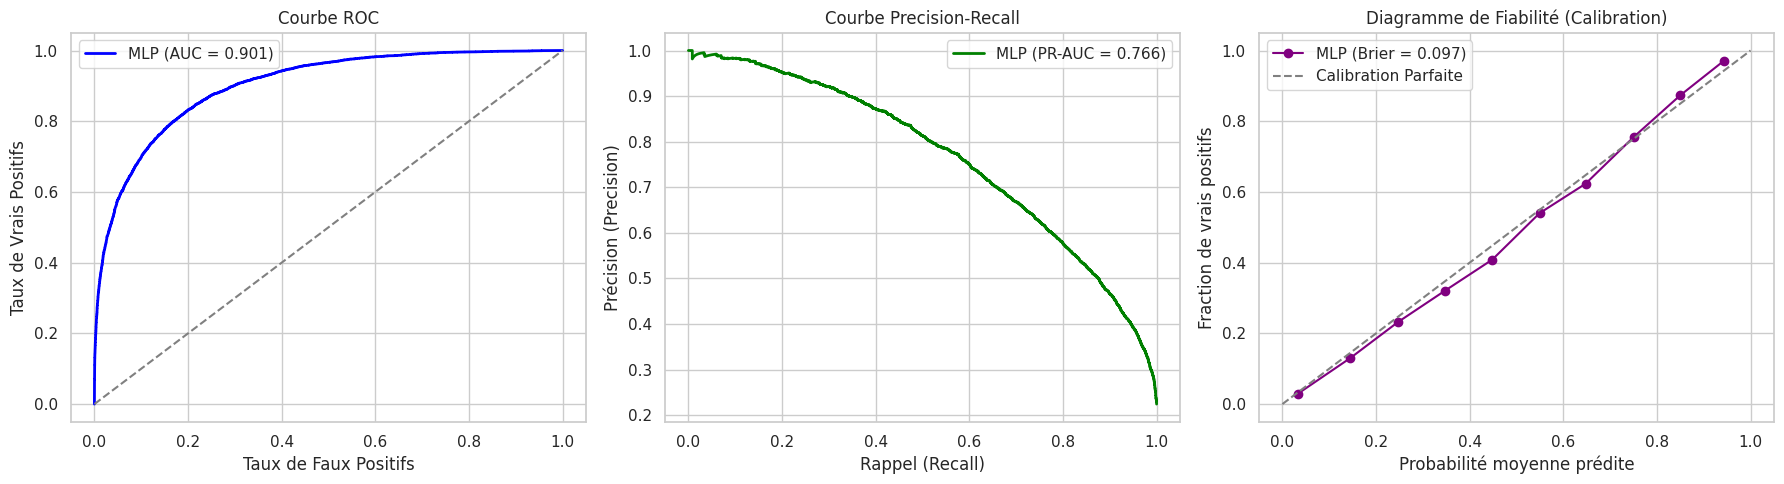

In [4]:
print("\nÉvaluation des performances et de la Calibration...")

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Courbe ROC (Critère : ROC-AUC)
fpr, tpr, _ = roc_curve(y_test_k, y_pred_proba_mlp)
roc_auc = auc(fpr, tpr)
ax[0].plot(fpr, tpr, color='blue', lw=2, label=f"MLP (AUC = {roc_auc:.3f})")
ax[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
ax[0].set_title("Courbe ROC")
ax[0].set_xlabel("Taux de Faux Positifs")
ax[0].set_ylabel("Taux de Vrais Positifs")
ax[0].legend()

# Courbe Precision-Recall 
precision, recall, _ = precision_recall_curve(y_test_k, y_pred_proba_mlp)
pr_auc = auc(recall, precision)
ax[1].plot(recall, precision, color='green', lw=2, label=f"MLP (PR-AUC = {pr_auc:.3f})")
ax[1].set_title("Courbe Precision-Recall")
ax[1].set_xlabel("Rappel (Recall)")
ax[1].set_ylabel("Précision (Precision)")
ax[1].legend()

# Courbe de Calibration / Fiabilité 
prob_true, prob_pred = calibration_curve(y_test_k, y_pred_proba_mlp, n_bins=10)
brier_score = brier_score_loss(y_test_k, y_pred_proba_mlp)
ax[2].plot(prob_pred, prob_true, marker='o', color='purple', label=f'MLP (Brier = {brier_score:.3f})')
ax[2].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Calibration Parfaite')
ax[2].set_title("Diagramme de Fiabilité (Calibration)")
ax[2].set_xlabel("Probabilité moyenne prédite")
ax[2].set_ylabel("Fraction de vrais positifs")
ax[2].legend()

plt.tight_layout()
plt.show()


 Calibration des probabilités du Réseau de Neurones...
--------------------------------------------------

 Log-Loss (Pénalité de fausse certitude) :
   - Brut    : 0.3136
   - Calibré : 0.3144 
--------------------------------------------------


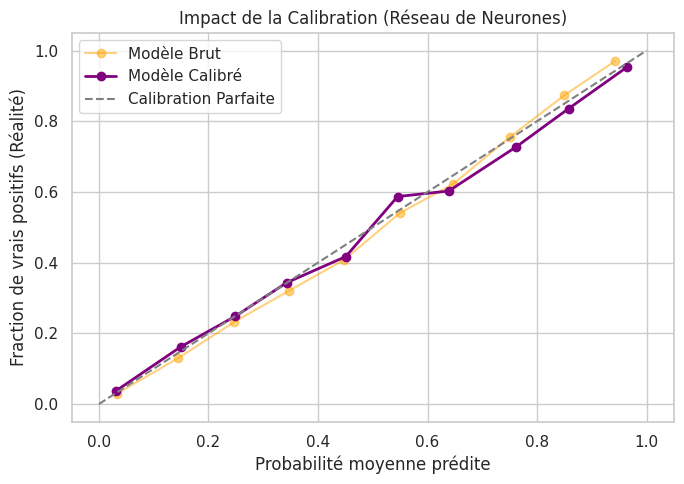

In [5]:

print("\n Calibration des probabilités du Réseau de Neurones...")

from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, log_loss


y_proba_mlp_raw = mlp_model.predict(X_test_k, verbose=0).ravel()

y_proba_train = mlp_model.predict(X_train, verbose=0).ravel()


calibrator = IsotonicRegression(out_of_bounds='clip')
calibrator.fit(y_proba_train, y_train)


y_proba_mlp_calib = calibrator.predict(y_proba_mlp_raw)


if 'mes_predictions_proba' not in globals():
    mes_predictions_proba = {}

# Sauvegarde des versions pour les graphiques
mes_predictions_proba["Deep_Learning_Brut"] = y_proba_mlp_raw
mes_predictions_proba["Deep_Learning_Calibre"] = y_proba_mlp_calib

# 3. Calcul des métriques de comparaison
brier_brut = brier_score_loss(y_test_k, y_proba_mlp_raw)
brier_calib = brier_score_loss(y_test_k, y_proba_mlp_calib)

logloss_brut = log_loss(y_test_k, y_proba_mlp_raw)
logloss_calib = log_loss(y_test_k, y_proba_mlp_calib)

# 4. Affichage des résultats pour le rapport
print("-" * 50)

print(f"\n Log-Loss (Pénalité de fausse certitude) :")
print(f"   - Brut    : {logloss_brut:.4f}")
print(f"   - Calibré : {logloss_calib:.4f} ")
print("-" * 50)

# 5. Tracé du diagramme de fiabilité
plt.figure(figsize=(7, 5))
prob_true_raw, prob_pred_raw = calibration_curve(y_test_k, y_proba_mlp_raw, n_bins=10)
prob_true_cal, prob_pred_cal = calibration_curve(y_test_k, y_proba_mlp_calib, n_bins=10)

plt.plot(prob_pred_raw, prob_true_raw, marker='o', label='Modèle Brut', color='orange', alpha=0.5)
plt.plot(prob_pred_cal, prob_true_cal, marker='o', label='Modèle Calibré', color='purple', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Calibration Parfaite')

plt.title("Impact de la Calibration (Réseau de Neurones)")
plt.xlabel("Probabilité moyenne prédite")
plt.ylabel("Fraction de vrais positifs (Réalité)")
plt.legend()
plt.tight_layout()
plt.show()


Analyse des erreurs de prédiction...


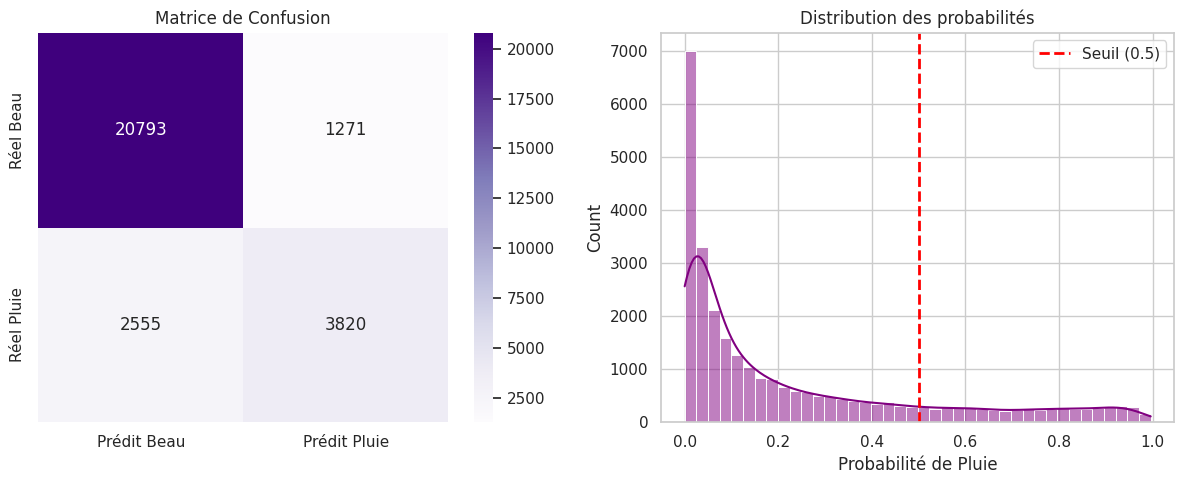


--- RAPPORT D'ANALYSE ---
Vrais Positifs (Pluie correctement prédite) : 3820
Faux Positifs (Fausse alerte pluie) : 1271
Faux Négatifs (Pluie non anticipée) : 2555

Rapport de classification complet :
              precision    recall  f1-score   support

  Beau temps       0.89      0.94      0.92     22064
       Pluie       0.75      0.60      0.67      6375

    accuracy                           0.87     28439
   macro avg       0.82      0.77      0.79     28439
weighted avg       0.86      0.87      0.86     28439



In [6]:
print("\nAnalyse des erreurs de prédiction...")

# Seuil à 0.5
y_pred_classes_mlp = (y_pred_proba_mlp > 0.5).astype(int)
conf_matrix_mlp = confusion_matrix(y_test_k, y_pred_classes_mlp)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Matrice de Confusion (Heatmap)
sns.heatmap(conf_matrix_mlp, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Prédit Beau', 'Prédit Pluie'], 
            yticklabels=['Réel Beau', 'Réel Pluie'], ax=ax[0])
ax[0].set_title("Matrice de Confusion")

# Distribution des probabilités
sns.histplot(y_pred_proba_mlp, bins=40, kde=True, color='purple', ax=ax[1])
ax[1].axvline(0.5, color='red', linestyle='--', lw=2, label='Seuil (0.5)')
ax[1].set_title("Distribution des probabilités")
ax[1].set_xlabel("Probabilité de Pluie")
ax[1].legend()

plt.tight_layout()
plt.show()

print("\n--- RAPPORT D'ANALYSE ---")
print(f"Vrais Positifs (Pluie correctement prédite) : {conf_matrix_mlp[1, 1]}")
print(f"Faux Positifs (Fausse alerte pluie) : {conf_matrix_mlp[0, 1]}")
print(f"Faux Négatifs (Pluie non anticipée) : {conf_matrix_mlp[1, 0]}")
print("\nRapport de classification complet :")
print(classification_report(y_test_k, y_pred_classes_mlp, target_names=['Beau temps', 'Pluie']))


 Interprétabilité : Variables influentes et PDP
Génération du PDP pour la variable principale : Humidity3pm


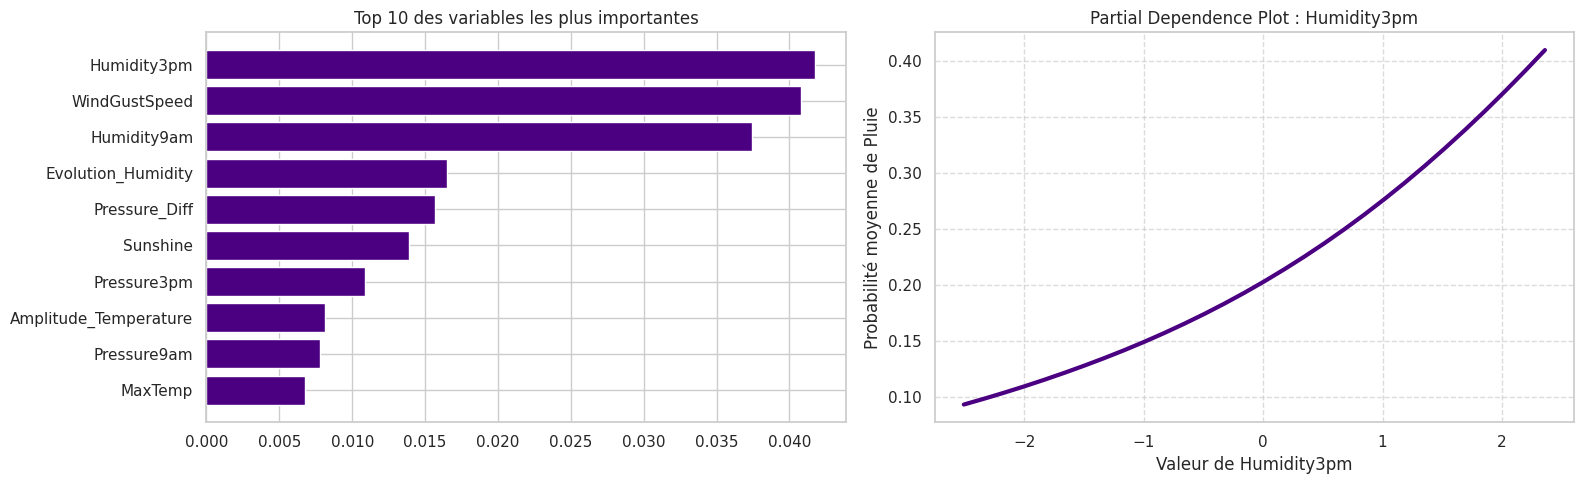

In [7]:
print("\n Interprétabilité : Variables influentes et PDP")

def compute_permutation_importance(model, X, y, metric=roc_auc_score, n_repeats=3):
    X_val = np.asarray(X).astype('float32')
    y_val = np.asarray(y).astype('float32')
    baseline_preds = model.predict(X_val, verbose=0).ravel()
    baseline_score = metric(y_val, baseline_preds)
    
    importances = []
    for i in range(X_val.shape[1]):
        scores_perm = []
        for _ in range(n_repeats):
            X_perm = X_val.copy()
            np.random.shuffle(X_perm[:, i])
            preds = model.predict(X_perm, verbose=0).ravel()
            scores_perm.append(metric(y_val, preds))
        importances.append(baseline_score - np.mean(scores_perm))
    return np.array(importances)

# 1. Permutation Importance (Échantillon pour ne pas bloquer Kaggle)
X_test_sample = X_test.sample(2000, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

importances_dl = compute_permutation_importance(mlp_model, X_test_sample, y_test_sample, n_repeats=3)
features = X_test.columns
indices = np.argsort(importances_dl)[::-1][:10]

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Graphique : Importance des variables
ax[0].barh(range(10), importances_dl[indices][::-1], align="center", color="indigo")
ax[0].set_yticks(range(10))
ax[0].set_yticklabels([features[i] for i in indices][::-1])
ax[0].set_title("Top 10 des variables les plus importantes")

# 2. CRITÈRE : Partial Dependence Plot (PDP) sur la variable N°1
top_feature = features[indices[0]]
print(f"Génération du PDP pour la variable principale : {top_feature}")

min_val, max_val = X_test[top_feature].min(), X_test[top_feature].max()
simulated_vals = np.linspace(min_val, max_val, 30)
mean_probs = []

for val in simulated_vals:
    X_sim = X_test.copy()
    X_sim[top_feature] = val
    preds = mlp_model.predict(np.asarray(X_sim).astype('float32'), verbose=0).ravel()
    mean_probs.append(preds.mean())

# Graphique : PDP
ax[1].plot(simulated_vals, mean_probs, color='indigo', lw=3)
ax[1].set_title(f"Partial Dependence Plot : {top_feature}")
ax[1].set_xlabel(f"Valeur de {top_feature}")
ax[1].set_ylabel("Probabilité moyenne de Pluie")
ax[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()